# Regressão Linear com o Dataset Iris

Neste notebook vamos aprender regressão linear na prática usando o famoso **Iris dataset**.

## Problema
O Iris dataset contém medidas de flores de íris. Vamos usar **regressão linear simples** para responder:

> "Dado o comprimento da pétala (`petal length`), qual é a largura da pétala (`petal width`)?"

Essas duas variáveis têm uma relação linear forte — perfeitas para aprender o algoritmo.

## O que vamos fazer
1. Explorar e visualizar os dados
2. Treinar um modelo de Regressão Linear
3. Avaliar o modelo com métricas
4. Visualizar a reta de regressão
5. Fazer predições com novos dados


---
## 1. Importações

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configuração visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


---
## 2. Carregando e Explorando o Dataset Iris

In [2]:
# Carregar o dataset
iris = load_iris()

# Criar DataFrame para facilitar a exploração
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print('=== Iris Dataset ===' )
print(f'Linhas: {df.shape[0]} | Colunas: {df.shape[1]}')
print(f'\nEspécies: {list(iris.target_names)}')
print(f'\nFeatures: {list(iris.feature_names)}')
print('\nPrimeiras 5 linhas:')
df.head()

=== Iris Dataset ===
Linhas: 150 | Colunas: 5

Espécies: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Primeiras 5 linhas:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# Estatísticas descritivas
print('=== Estatísticas Descritivas ===')
df.describe().round(2)

---
## 3. Visualização Exploratória dos Dados (EDA)

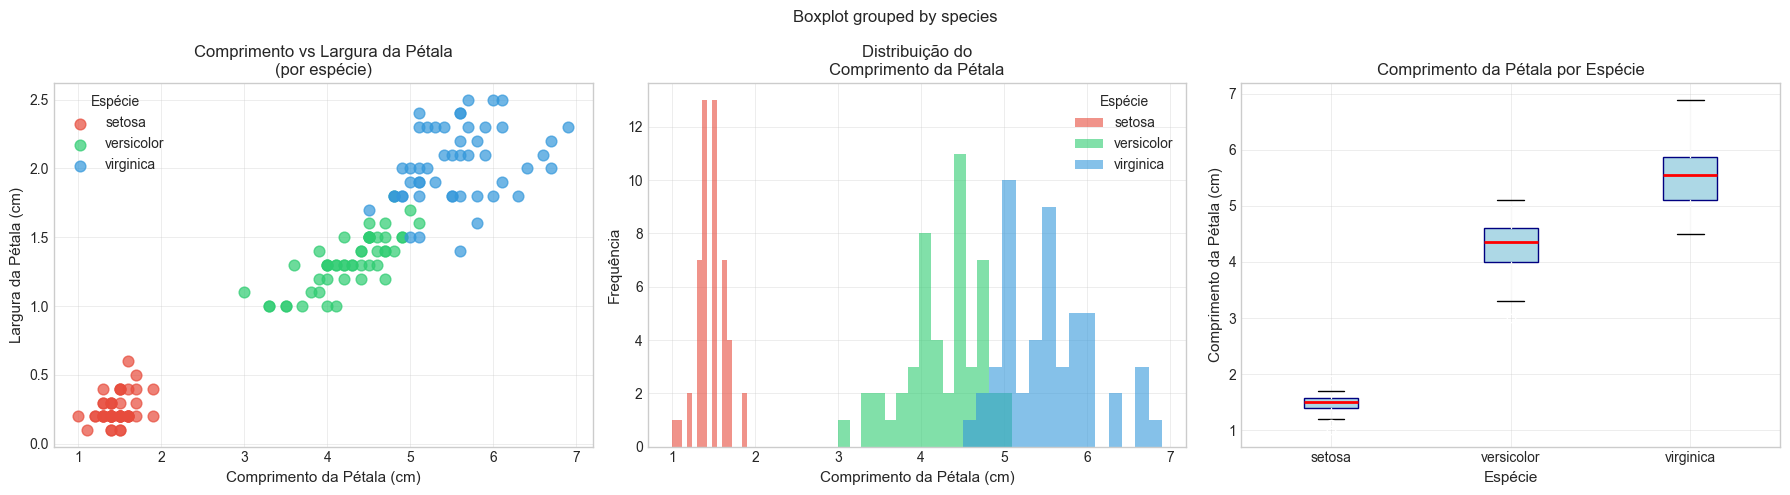

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Iris Dataset — Exploração Visual', fontsize=16, fontweight='bold')

colors = {'setosa': '#e74c3c', 'versicolor': '#2ecc71', 'virginica': '#3498db'}

# Plot 1: Distribuição das features
ax1 = axes[0]
for species in df['species'].unique():
    subset = df[df['species'] == species]
    ax1.scatter(subset['petal length (cm)'], subset['petal width (cm)'],
                label=species, alpha=0.7, s=60, color=colors[species])
ax1.set_xlabel('Comprimento da Pétala (cm)', fontsize=11)
ax1.set_ylabel('Largura da Pétala (cm)', fontsize=11)
ax1.set_title('Comprimento vs Largura da Pétala\n(por espécie)', fontsize=12)
ax1.legend(title='Espécie')

# Plot 2: Histograma - Comprimento da Pétala
ax2 = axes[1]
for species in df['species'].unique():
    subset = df[df['species'] == species]
    ax2.hist(subset['petal length (cm)'], bins=15, alpha=0.6,
             label=species, color=colors[species])
ax2.set_xlabel('Comprimento da Pétala (cm)', fontsize=11)
ax2.set_ylabel('Frequência', fontsize=11)
ax2.set_title('Distribuição do\nComprimento da Pétala', fontsize=12)
ax2.legend(title='Espécie')

# Plot 3: Boxplot por espécie
ax3 = axes[2]
df.boxplot(column='petal length (cm)', by='species', ax=ax3,
           patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'),
           medianprops=dict(color='red', linewidth=2))
ax3.set_title('Comprimento da Pétala\npor Espécie', fontsize=12)
ax3.set_xlabel('Espécie', fontsize=11)
ax3.set_ylabel('Comprimento da Pétala (cm)', fontsize=11)
plt.sca(ax3)
plt.title('Comprimento da Pétala por Espécie', fontsize=12)

plt.tight_layout()
plt.show()

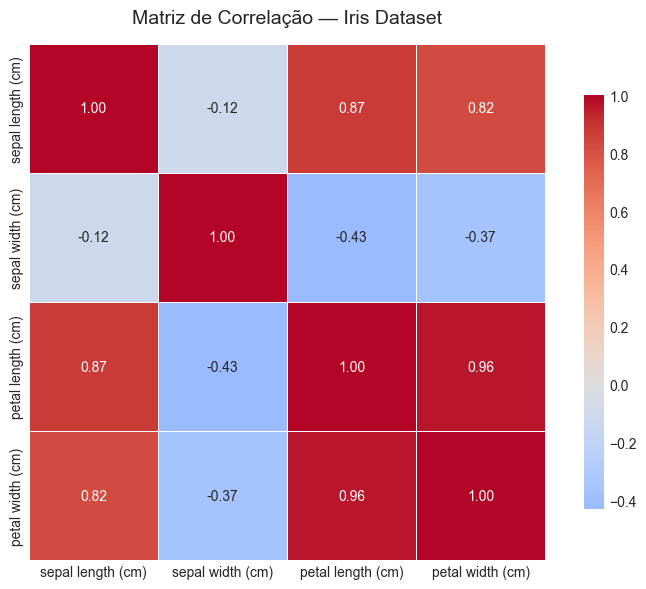


 Correlação entre comprimento e largura da pétala: 0.9629
→ Correlação muito forte! Ideal para regressão linear.


In [4]:
# Matriz de correlação
plt.figure(figsize=(8, 6))
corr_matrix = df.drop(columns='species').corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlação — Iris Dataset', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

corr_value = df['petal length (cm)'].corr(df['petal width (cm)'])
print(f'\n Correlação entre comprimento e largura da pétala: {corr_value:.4f}')
print('→ Correlação muito forte! Ideal para regressão linear.')

---
## 4. Preparando os Dados para o Modelo

**Feature (X):** `petal length (cm)` — variável de entrada  
**Target (y):** `petal width (cm)` — variável que queremos prever

**Fórmula que o modelo vai aprender:**
```
largura_petala = β₀ + β₁ × comprimento_petala
```

In [5]:
# Separar feature e target
X = df[['petal length (cm)']].values  # 2D array (necessário para sklearn)
y = df['petal width (cm)'].values     # 1D array

print(f'X shape: {X.shape}  (150 amostras, 1 feature)')
print(f'y shape: {y.shape}  (150 valores alvo)')
print(f'\nPrimeiros valores de X (comprimento): {X[:5].flatten()}')
print(f'Primeiros valores de y (largura):     {y[:5]}')

X shape: (150, 1)  (150 amostras, 1 feature)
y shape: (150,)  (150 valores alvo)

Primeiros valores de X (comprimento): [1.4 1.4 1.3 1.5 1.4]
Primeiros valores de y (largura):     [0.2 0.2 0.2 0.2 0.2]


In [6]:
# Dividir em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% para teste
    random_state=42   # semente para reprodutibilidade
)

print('=== Divisão Treino / Teste ===')
print(f'Total de amostras:  {len(X)}')
print(f'Amostras de treino: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)')
print(f'Amostras de teste:  {len(X_test)}  ({len(X_test)/len(X)*100:.0f}%)')

=== Divisão Treino / Teste ===
Total de amostras:  150
Amostras de treino: 120 (80%)
Amostras de teste:  30  (20%)


---
## 5. Treinando o Modelo

In [7]:
# Instanciar e treinar o modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Parâmetros aprendidos
beta_0 = model.intercept_
beta_1 = model.coef_[0]

print('=== Modelo Treinado! ===')
print(f'\n  Intercepto (β₀): {beta_0:.4f}')
print(f'  Coeficiente (β₁): {beta_1:.4f}')
print(f'\n  Equação aprendida:')
print(f'  largura_petala = {beta_0:.4f} + {beta_1:.4f} × comprimento_petala')
print(f'\n  Interpretação:')
print(f'  → Para cada 1cm a mais no comprimento da pétala,')
print(f'    a largura aumenta em {beta_1:.4f} cm')

=== Modelo Treinado! ===

  Intercepto (β₀): -0.3567
  Coeficiente (β₁): 0.4132

  Equação aprendida:
  largura_petala = -0.3567 + 0.4132 × comprimento_petala

  Interpretação:
  → Para cada 1cm a mais no comprimento da pétala,
    a largura aumenta em 0.4132 cm


---
## 6. Avaliando o Modelo

Vamos calcular as métricas no conjunto de **teste** (dados que o modelo nunca viu).

In [8]:
# Fazer predições no conjunto de teste
y_pred = model.predict(X_test)

# Calcular métricas
r2  = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print('=== Métricas de Avaliação (conjunto de teste) ===')
print(f'\n  R²   (Coef. de Determinação): {r2:.4f}')
print(f'  MSE  (Erro Quadrático Médio):  {mse:.4f}')
print(f'  RMSE (Raiz do MSE):            {rmse:.4f} cm')
print(f'  MAE  (Erro Absoluto Médio):    {mae:.4f} cm')

print(f'\n  Interpretação:')
print(f'  → R² = {r2:.2%} → o modelo explica {r2:.2%} da variação nos dados')
print(f'  → Em média, o modelo erra {mae:.4f} cm na largura da pétala')

=== Métricas de Avaliação (conjunto de teste) ===

  R²   (Coef. de Determinação): 0.9283
  MSE  (Erro Quadrático Médio):  0.0456
  RMSE (Raiz do MSE):            0.2136 cm
  MAE  (Erro Absoluto Médio):    0.1682 cm

  Interpretação:
  → R² = 92.83% → o modelo explica 92.83% da variação nos dados
  → Em média, o modelo erra 0.1682 cm na largura da pétala


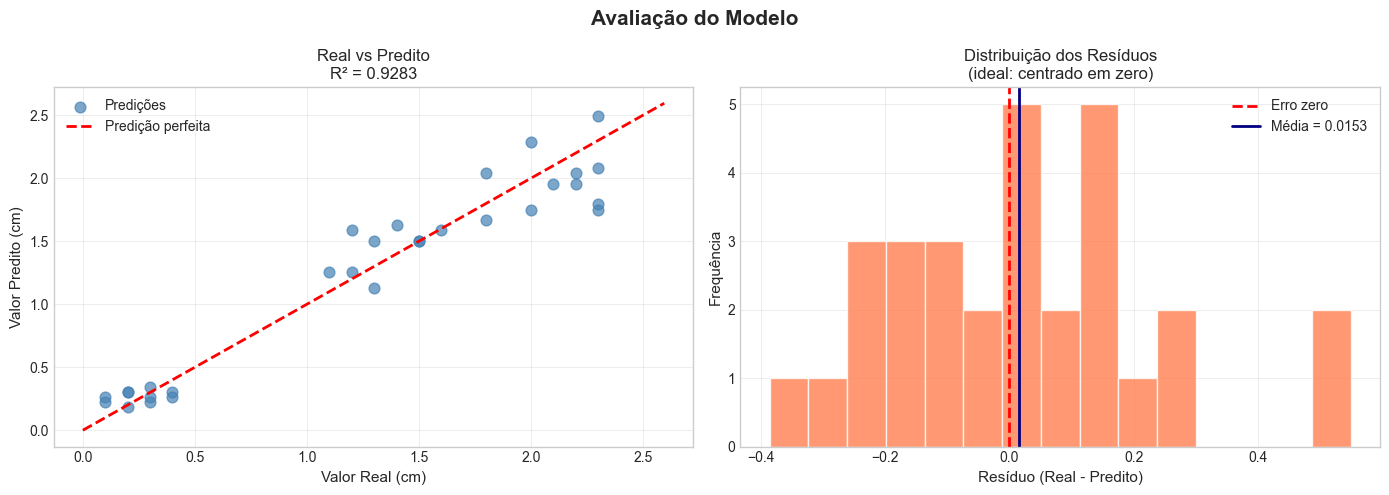

In [9]:
# Visualização: valores reais vs preditos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Avaliação do Modelo', fontsize=15, fontweight='bold')

# Plot 1: Real vs Predito
ax1 = axes[0]
ax1.scatter(y_test, y_pred, alpha=0.7, color='steelblue', s=60, label='Predições')
min_val = min(y_test.min(), y_pred.min()) - 0.1
max_val = max(y_test.max(), y_pred.max()) + 0.1
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predição perfeita')
ax1.set_xlabel('Valor Real (cm)', fontsize=11)
ax1.set_ylabel('Valor Predito (cm)', fontsize=11)
ax1.set_title(f'Real vs Predito\nR² = {r2:.4f}', fontsize=12)
ax1.legend()

# Plot 2: Distribuição dos resíduos
ax2 = axes[1]
residuos = y_test - y_pred
ax2.hist(residuos, bins=15, color='coral', edgecolor='white', alpha=0.8)
ax2.axvline(0, color='red', linestyle='--', lw=2, label='Erro zero')
ax2.axvline(residuos.mean(), color='navy', linestyle='-', lw=2,
            label=f'Média = {residuos.mean():.4f}')
ax2.set_xlabel('Resíduo (Real - Predito)', fontsize=11)
ax2.set_ylabel('Frequência', fontsize=11)
ax2.set_title('Distribuição dos Resíduos\n(ideal: centrado em zero)', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()

---
## 7. Visualizando a Reta de Regressão

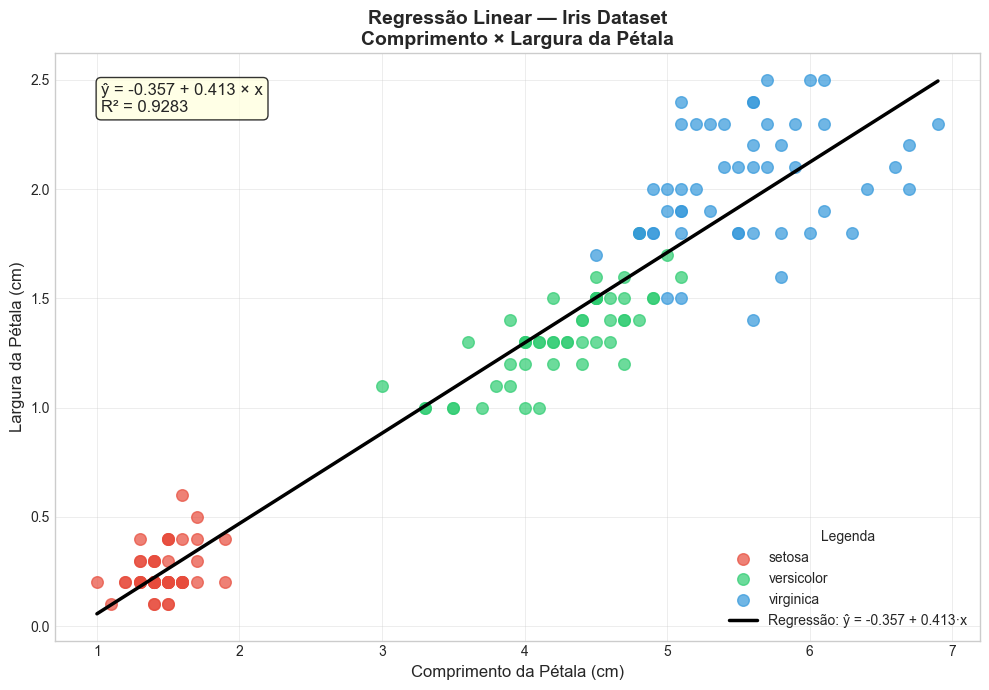

In [10]:
plt.figure(figsize=(10, 7))

# Scatter plot com cores por espécie
colors_map = {'setosa': '#e74c3c', 'versicolor': '#2ecc71', 'virginica': '#3498db'}
for species in df['species'].unique():
    subset = df[df['species'] == species]
    plt.scatter(subset['petal length (cm)'], subset['petal width (cm)'],
                label=f'{species}', alpha=0.7, s=70,
                color=colors_map[species], zorder=3)

# Reta de regressão
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)
plt.plot(x_line, y_line, color='black', lw=2.5,
         label=f'Regressão: ŷ = {beta_0:.3f} + {beta_1:.3f}·x',
         zorder=4)

# Anotação da equação
equation_text = f'ŷ = {beta_0:.3f} + {beta_1:.3f} × x\nR² = {r2:.4f}'
plt.text(0.05, 0.95, equation_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.xlabel('Comprimento da Pétala (cm)', fontsize=12)
plt.ylabel('Largura da Pétala (cm)', fontsize=12)
plt.title('Regressão Linear — Iris Dataset\nComprimento × Largura da Pétala', fontsize=14, fontweight='bold')
plt.legend(title='Legenda', fontsize=10)
plt.tight_layout()
plt.show()

---
## 8. Fazendo Predições com Novos Dados

Aqui simulamos o uso real do modelo: dados chegam, o modelo prediz.

In [11]:
# Exemplos de predição
novos_comprimentos = np.array([[1.0], [3.0], [4.5], [6.0], [7.0]])

predicoes = model.predict(novos_comprimentos)

print('=== Predições do Modelo ===')
print(f'\n  {"Comprimento (cm)":>18} | {"Largura Prevista (cm)":>22}')
print(f'  {"-"*18}-+-{"-"*22}')
for comp, larg in zip(novos_comprimentos.flatten(), predicoes):
    print(f'  {comp:>18.1f} | {larg:>22.4f}')

print(f'\n  Lembre: ŷ = {beta_0:.4f} + {beta_1:.4f} × x')
print(f'  Ex: pétala de 4.5 cm → {beta_0:.4f} + {beta_1:.4f} × 4.5 = {beta_0 + beta_1 * 4.5:.4f} cm')

=== Predições do Modelo ===

    Comprimento (cm) |  Largura Prevista (cm)
  -------------------+-----------------------
                 1.0 |                 0.0566
                 3.0 |                 0.8830
                 4.5 |                 1.5029
                 6.0 |                 2.1228
                 7.0 |                 2.5360

  Lembre: ŷ = -0.3567 + 0.4132 × x
  Ex: pétala de 4.5 cm → -0.3567 + 0.4132 × 4.5 = 1.5029 cm


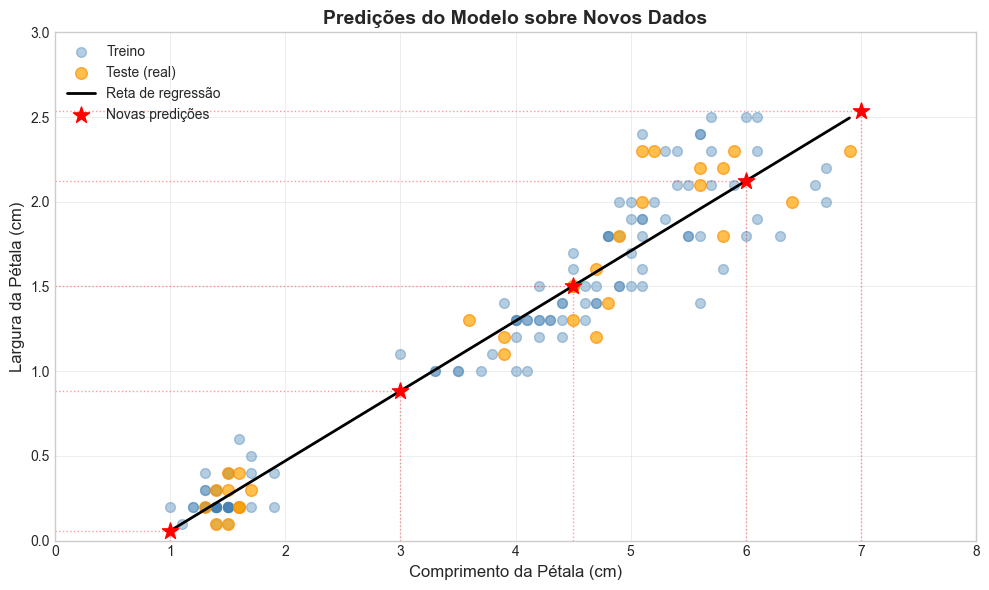

In [12]:
# Visualização das predições sobre novos dados
plt.figure(figsize=(10, 6))

# Dados de treino e teste
plt.scatter(X_train, y_train, alpha=0.4, color='steelblue', s=50, label='Treino', zorder=2)
plt.scatter(X_test, y_test, alpha=0.7, color='orange', s=70,
            edgecolors='darkorange', label='Teste (real)', zorder=3)

# Reta de regressão
plt.plot(x_line, y_line, color='black', lw=2, label='Reta de regressão', zorder=4)

# Novos pontos preditos
plt.scatter(novos_comprimentos, predicoes, color='red', s=150,
            marker='*', zorder=5, label='Novas predições')

# Linhas pontilhadas para os novos pontos
for comp, pred in zip(novos_comprimentos.flatten(), predicoes):
    plt.plot([comp, comp], [0, pred], 'r:', alpha=0.4, lw=1)
    plt.plot([0, comp], [pred, pred], 'r:', alpha=0.4, lw=1)

plt.xlabel('Comprimento da Pétala (cm)', fontsize=12)
plt.ylabel('Largura da Pétala (cm)', fontsize=12)
plt.title('Predições do Modelo sobre Novos Dados', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.xlim(0, 8)
plt.ylim(0, 3)
plt.tight_layout()
plt.show()

---
## 9. Teste Passo a Passo — Verificação Manual

Vamos calcular uma predição à mão para entender exatamente o que o modelo faz.

In [13]:
# Escolher uma amostra do conjunto de teste
idx = 0  # primeira amostra de teste
x_exemplo = X_test[idx][0]
y_real = y_test[idx]

# Cálculo manual
y_manual = beta_0 + beta_1 * x_exemplo

# Cálculo via modelo
y_modelo = model.predict([[x_exemplo]])[0]

print('=== Verificação Manual ===')
print(f'\n  Entrada (comprimento da pétala): {x_exemplo:.1f} cm')
print(f'\n  Cálculo manual:')
print(f'  ŷ = {beta_0:.4f} + {beta_1:.4f} × {x_exemplo:.1f}')
print(f'  ŷ = {beta_0:.4f} + {beta_1 * x_exemplo:.4f}')
print(f'  ŷ = {y_manual:.4f} cm')
print(f'\n  Predição do modelo:  {y_modelo:.4f} cm')
print(f'  Valor real:          {y_real:.4f} cm')
print(f'  Erro (resíduo):      {abs(y_real - y_modelo):.4f} cm')
print(f'\n  Manual == Modelo? {np.isclose(y_manual, y_modelo)}')

=== Verificação Manual ===

  Entrada (comprimento da pétala): 4.7 cm

  Cálculo manual:
  ŷ = -0.3567 + 0.4132 × 4.7
  ŷ = -0.3567 + 1.9422
  ŷ = 1.5856 cm

  Predição do modelo:  1.5856 cm
  Valor real:          1.2000 cm
  Erro (resíduo):      0.3856 cm

  Manual == Modelo? True


---
## 10. Resumo Final

In [14]:
print('=' * 55)
print('           RESUMO DO MODELO TREINADO')
print('=' * 55)
print()
print('  PROBLEMA')
print('  Prever a largura da pétala a partir do comprimento')
print()
print('  EQUAÇÃO APRENDIDA')
print(f'  ŷ = {beta_0:.4f} + {beta_1:.4f} × comprimento_petala')
print()
print('  DADOS')
print(f'  Total: 150 amostras')
print(f'  Treino: 120 | Teste: 30')
print()
print('  MÉTRICAS (conjunto de teste)')
print(f'  R²   = {r2:.4f}  ({r2:.2%} da variância explicada)')
print(f'  RMSE = {rmse:.4f} cm')
print(f'  MAE  = {mae:.4f} cm')
print()
print('  INTERPRETAÇÃO')
print(f'  Para cada 1 cm a mais no comprimento da pétala,')
print(f'  a largura aumenta em {beta_1:.4f} cm')
print('=' * 55)

           RESUMO DO MODELO TREINADO

  PROBLEMA
  Prever a largura da pétala a partir do comprimento

  EQUAÇÃO APRENDIDA
  ŷ = -0.3567 + 0.4132 × comprimento_petala

  DADOS
  Total: 150 amostras
  Treino: 120 | Teste: 30

  MÉTRICAS (conjunto de teste)
  R²   = 0.9283  (92.83% da variância explicada)
  RMSE = 0.2136 cm
  MAE  = 0.1682 cm

  INTERPRETAÇÃO
  Para cada 1 cm a mais no comprimento da pétala,
  a largura aumenta em 0.4132 cm


---
## Próximos Passos

Agora que você entende regressão linear simples, explore:

1. **Regressão Linear Múltipla** — use todas as 4 features do Iris
2. **Regularização** — Ridge (L2) e Lasso (L1) para evitar overfitting
3. **Outros datasets** — Boston Housing, California Housing
4. **Validação Cruzada** — `cross_val_score` para avaliação mais robusta

```python
# Exemplo: Regressão Múltipla com todas as features
X_multi = iris.data[:, :3]  # 3 primeiras features
y_target = iris.data[:, 3]  # petal width
model_multi = LinearRegression().fit(X_multi, y_target)
```